# CS3807 Deep Learning Lab - Experiment 2
## Implementation of a Multi-Layer Perceptron (MLP) for Multi-Class Image Classification (Fashion-MNIST)

In [3]:
# CELL 1 - Setup

!pip install -q "scikit-learn<1.6" scikeras
!apt-get -qq install -y fonts-liberation > /dev/null 2>&1

import os
import time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from scikeras.wrappers import KerasClassifier

RANDOM_STATE = 109
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

os.makedirs("plots", exist_ok=True)

fm.fontManager.addfont("/usr/share/fonts/truetype/liberation/LiberationSerif-Regular.ttf")
fm.fontManager.addfont("/usr/share/fonts/truetype/liberation/LiberationSerif-Bold.ttf")

# Global plot styling - Times New Roman (Liberation Serif substitute), 14pt,
# bold axis labels and legend text, as required for the report.
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Liberation Serif']
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
LEGEND_PROP = {'weight': 'bold', 'family': 'serif', 'size': 14}

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def save_fig(fig, name, dpi=600):
    fig.savefig(f"plots/{name}.eps", format="eps", dpi=dpi, bbox_inches="tight")
    plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 84.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train images: (60000, 28, 28) Train labels: (60000,)
Test images: (10000, 28, 28) Test labels: (10000,)


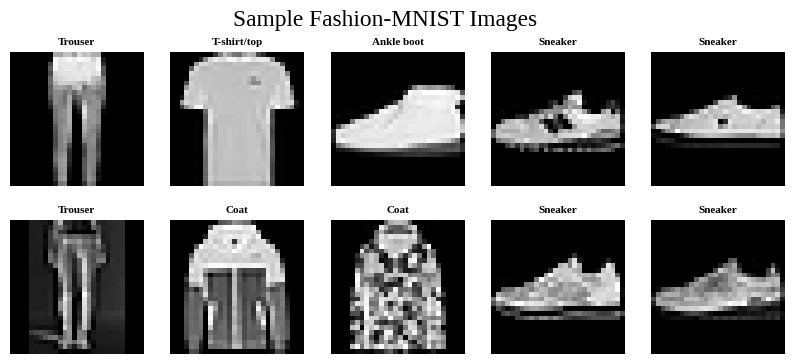

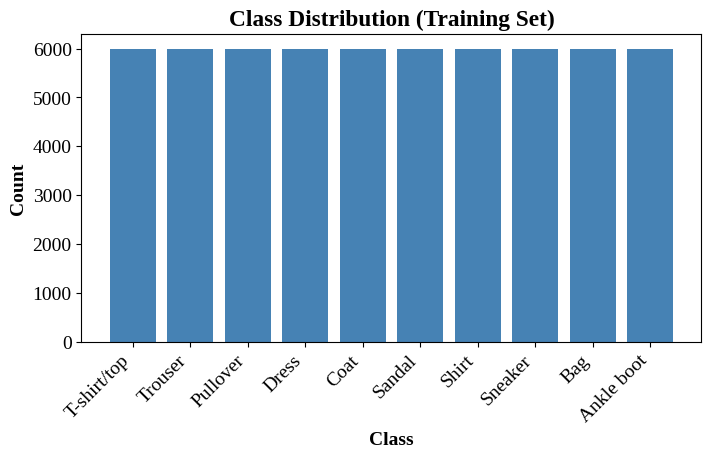

In [4]:
# CELL 2 - Task 1: Dataset Exploration
(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

print("Train images:", x_train_raw.shape, "Train labels:", y_train_raw.shape)
print("Test images:", x_test_raw.shape, "Test labels:", y_test_raw.shape)

# Plot 1: Sample Images
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(x_train_raw), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(x_train_raw[idx], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train_raw[idx]], fontsize=8)
    ax.axis('off')
fig.suptitle("Sample Fashion-MNIST Images")
save_fig(fig, "01_sample_images", dpi=150)

# Plot 2: Class Distribution
unique, counts = np.unique(y_train_raw, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue')
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Class Distribution (Training Set)")
plt.xticks(rotation=45, ha='right')
save_fig(fig, "02_class_distribution")

In [5]:
# CELL 3 - Task 2: Data Preprocessing
print("Before preprocessing:", x_train_raw.shape, x_train_raw.dtype)

# Flatten each 28x28 image into a 784-length vector and scale pixels to [0, 1]
x_train = x_train_raw.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test_raw.reshape(-1, 784).astype("float32") / 255.0

# One-hot encode the labels
y_train = keras.utils.to_categorical(y_train_raw, 10)
y_test = keras.utils.to_categorical(y_test_raw, 10)

print("After preprocessing:", x_train.shape, x_train.dtype)
print("One-hot label shape:", y_train.shape)

Before preprocessing: (60000, 28, 28) uint8
After preprocessing: (60000, 784) float32
One-hot label shape: (60000, 10)


In [6]:
# CELL 4 - Task 3: Model Construction
baseline_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8202 - loss: 0.5026 - val_accuracy: 0.8602 - val_loss: 0.3966
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8647 - loss: 0.3716 - val_accuracy: 0.8727 - val_loss: 0.3476
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8780 - loss: 0.3321 - val_accuracy: 0.8780 - val_loss: 0.3406
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8877 - loss: 0.3074 - val_accuracy: 0.8775 - val_loss: 0.3372
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8937 - loss: 0.2883 - val_accuracy: 0.8787 - val_loss: 0.3321
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8986 - loss: 0.2722 - val_accuracy: 0.8812 - val_loss: 0.3342
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9034 - loss: 0.2600 - val_accuracy: 0.8782 - val_loss: 0.3374
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9088 - loss: 0.2463 

Baseline training time: 125.23s


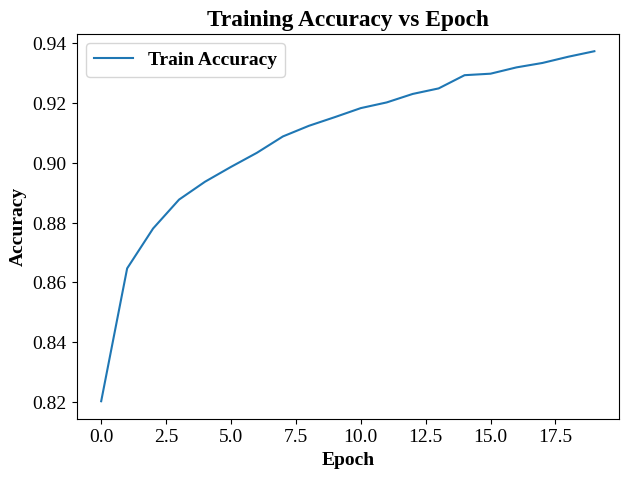

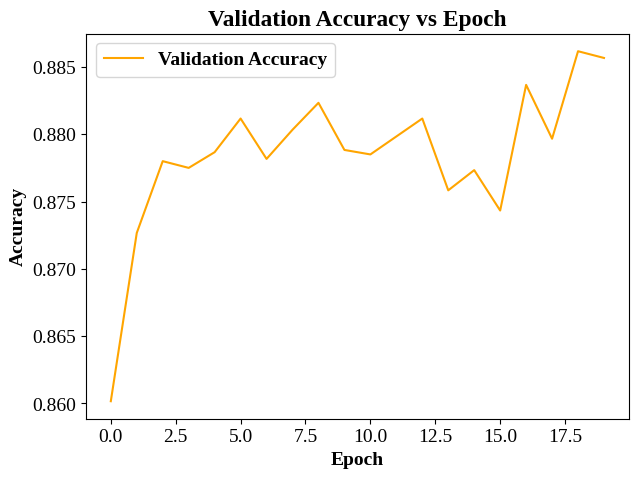

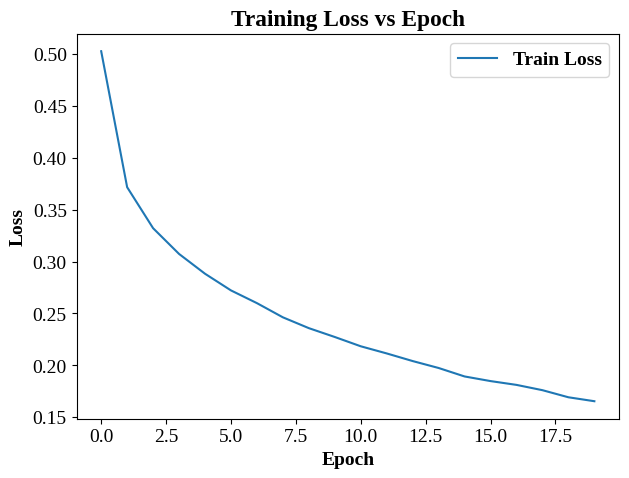

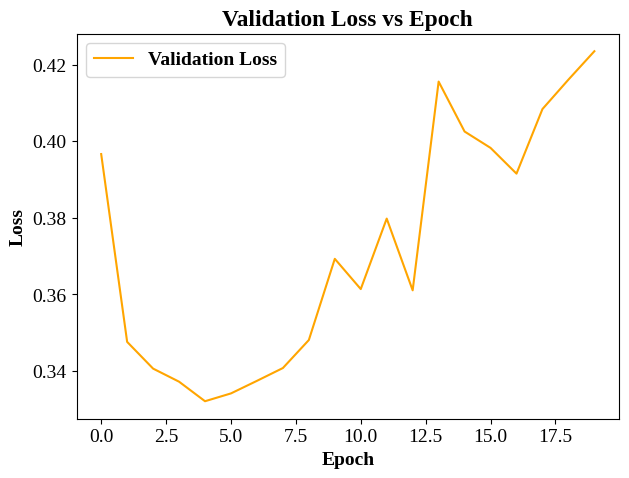

In [7]:
# CELL 5 - Task 4: Model Training
baseline_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

start_time = time.time()
history = baseline_model.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)
baseline_train_time = time.time() - start_time
print(f"Baseline training time: {baseline_train_time:.2f}s")

# Plot 3: Training Accuracy vs Epoch
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history.history['accuracy'], label='Train Accuracy')
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Training Accuracy vs Epoch")
ax.legend(prop=LEGEND_PROP)
save_fig(fig, "03_train_accuracy")

# Plot 4: Validation Accuracy vs Epoch
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Validation Accuracy vs Epoch")
ax.legend(prop=LEGEND_PROP)
save_fig(fig, "04_val_accuracy")

# Plot 5: Training Loss vs Epoch
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history.history['loss'], label='Train Loss')
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Training Loss vs Epoch")
ax.legend(prop=LEGEND_PROP)
save_fig(fig, "05_train_loss")

# Plot 6: Validation Loss vs Epoch
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Validation Loss vs Epoch")
ax.legend(prop=LEGEND_PROP)
save_fig(fig, "06_val_loss")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
--- Baseline ---
Accuracy: 0.8809  Precision: 0.8828  Recall: 0.8809  F1: 0.8813
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.80      0.82      1000
     Trouser       0.99      0.96      0.98      1000
    Pullover       0.80      0.79      0.80      1000
       Dress       0.87      0.88      0.87      1000
        Coat       0.75      0.83      0.79      1000
      Sandal       0.99      0.95      0.97      1000
       Shirt       0.71      0.70      0.70      1000
     Sneaker       0.93      0.98      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



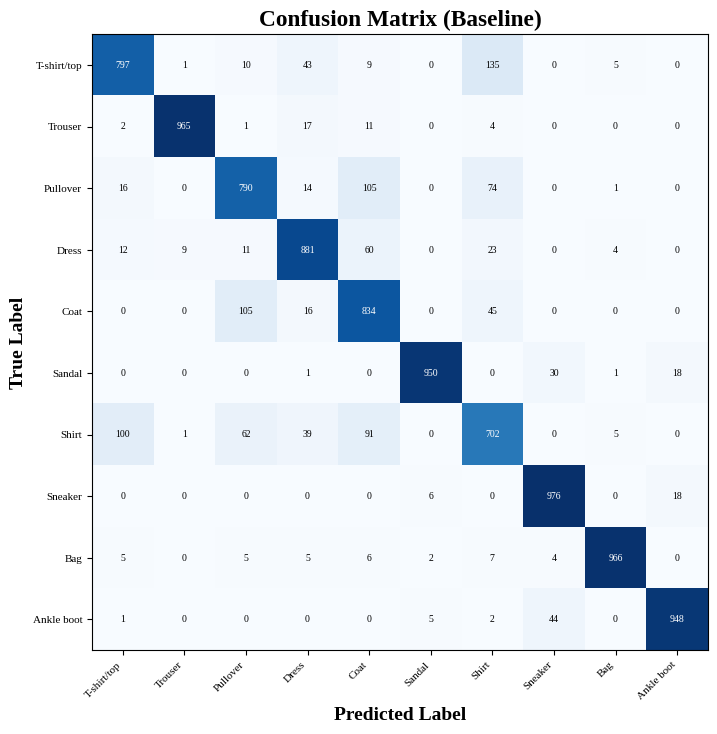

In [13]:
# CELL 6 - Task 5: Model Evaluation
def evaluate_model(model, x_test, y_test_labels, name=""):
    y_pred_probs = model.predict(x_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    acc = accuracy_score(y_test_labels, y_pred)
    prec = precision_score(y_test_labels, y_pred, average='macro')
    rec = recall_score(y_test_labels, y_pred, average='macro')
    f1 = f1_score(y_test_labels, y_pred, average='macro')
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    print(classification_report(y_test_labels, y_pred, target_names=CLASS_NAMES))
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "y_pred": y_pred}

baseline_results = evaluate_model(baseline_model, x_test, y_test_raw, "Baseline")

# Plot 7: Confusion Matrix
cm = confusion_matrix(y_test_raw, baseline_results["y_pred"])

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(np.arange(10)); ax.set_yticks(np.arange(10))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(CLASS_NAMES, fontsize=8)
for i in range(10):
    for j in range(10):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=7)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Confusion Matrix (Baseline)")
save_fig(fig, "07_confusion_matrix", dpi=150)

Fitting 5 folds for each of 15 candidates, totalling 75 fits
[CV] END batch_size=128, epochs=30, model__activation=sigmoid, model__dropout_rate=0.2, model__hidden_layers=3, model__hidden_neurons=32, model__learning_rate=0.001, model__optimizer_name=sgd; total time=  13.6s
[CV] END batch_size=128, epochs=30, model__activation=sigmoid, model__dropout_rate=0.2, model__hidden_layers=3, model__hidden_neurons=32, model__learning_rate=0.001, model__optimizer_name=sgd; total time=  16.0s
[CV] END batch_size=128, epochs=30, model__activation=sigmoid, model__dropout_rate=0.2, model__hidden_layers=3, model__hidden_neurons=32, model__learning_rate=0.001, model__optimizer_name=sgd; total time=  12.8s
[CV] END batch_size=128, epochs=30, model__activation=sigmoid, model__dropout_rate=0.2, model__hidden_layers=3, model__hidden_neurons=32, model__learning_rate=0.001, model__optimizer_name=sgd; total time=  13.1s
[CV] END batch_size=128, epochs=30, model__activation=sigmoid, model__dropout_rate=0.2, mod

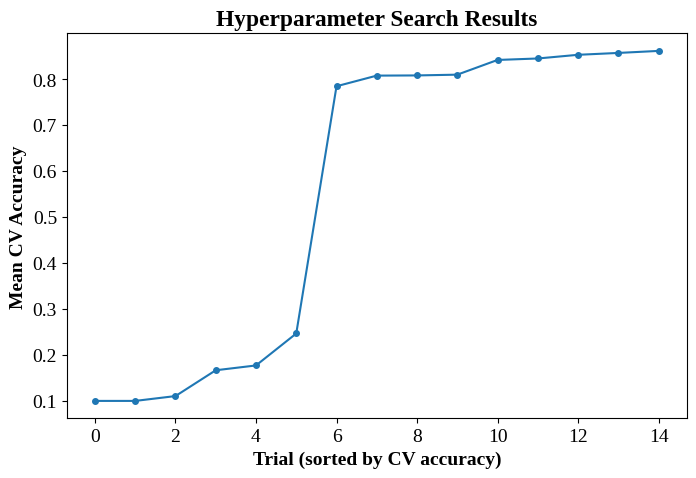

In [9]:
# CELL 7 - Hyperparameter Optimization (Task 1-3 of Section 7)
# RandomizedSearchCV with 5-fold CV over the full search space is not
# practical on the full 60,000 images (5 folds x n_iter model fits), so the
# search is run on a stratified 15,000-image subsample. The final model is
# still retrained on the full training set in the next cell.

x_search, _, y_search, _ = train_test_split(
    x_train, y_train_raw, train_size=15000,
    stratify=y_train_raw, random_state=RANDOM_STATE
)

def build_tunable_model(hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                         optimizer_name='adam', activation='relu', dropout_rate=0.0):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation='softmax'))

    opt_map = {
        'sgd': keras.optimizers.SGD(learning_rate=learning_rate),
        'adam': keras.optimizers.Adam(learning_rate=learning_rate),
        'rmsprop': keras.optimizers.RMSprop(learning_rate=learning_rate),
    }
    model.compile(optimizer=opt_map[optimizer_name],
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

clf = KerasClassifier(
    model=build_tunable_model,
    hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
    optimizer_name='adam', activation='relu', dropout_rate=0.0,
    epochs=10, batch_size=32, verbose=0
)

param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__hidden_neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__optimizer_name": ["sgd", "adam", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=15,
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=2
)

search.fit(x_search, y_search)

print("Best params:", search.best_params_)
print("Best CV accuracy:", search.best_score_)

# Plot 8: Hyperparameter Search Results
scores = search.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(len(scores)), sorted(scores), marker='o', markersize=4)
ax.set_xlabel("Trial (sorted by CV accuracy)")
ax.set_ylabel("Mean CV Accuracy")
ax.set_title("Hyperparameter Search Results")
save_fig(fig, "08_hyperparameter_search")

Epoch 1/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8002 - loss: 0.5575 - val_accuracy: 0.8403 - val_loss: 0.4445
Epoch 2/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.8456 - loss: 0.4306 - val_accuracy: 0.8522 - val_loss: 0.4121
Epoch 3/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8574 - loss: 0.3980 - val_accuracy: 0.8600 - val_loss: 0.4053
Epoch 4/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8658 - loss: 0.3808 - val_accuracy: 0.8680 - val_loss: 0.3737
Epoch 5/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8699 - loss: 0.3656 - val_accuracy: 0.8650 - val_loss: 0.3865
Epoch 6/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8732 - loss: 0.3557 - val_accuracy: 0.8677 - val_loss: 0.3851
Epoch 7/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8777 - loss: 0.3487 - val_accuracy: 0.8608 - val_loss: 0.3953
Epoch 8/30
3375/3375 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8801 - loss: 0.

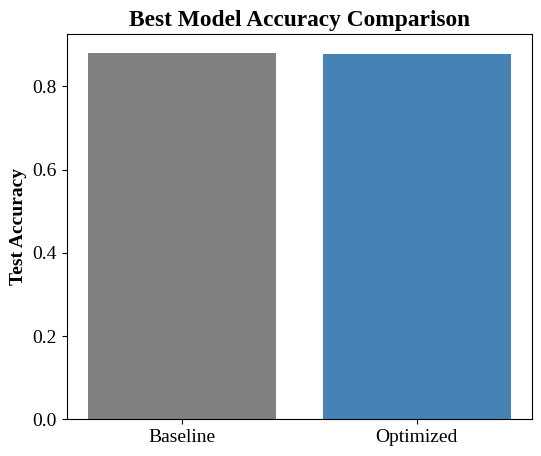

In [10]:
# CELL 8 - Retrain Optimized Model and Compare (Task 4-7 of Section 7)
best_params = {k.replace("model__", ""): v for k, v in search.best_params_.items()
               if k.startswith("model__")}
best_epochs = search.best_params_.get("epochs", 20)
best_batch = search.best_params_.get("batch_size", 32)

optimized_model = build_tunable_model(**best_params)

start_time = time.time()
opt_history = optimized_model.fit(
    x_train, y_train_raw,
    validation_split=0.1,
    epochs=best_epochs,
    batch_size=best_batch,
    verbose=1
)
optimized_train_time = time.time() - start_time

optimized_results = evaluate_model(optimized_model, x_test, y_test_raw, "Optimized")

# Plot 9: Best Model Accuracy Comparison
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(["Baseline", "Optimized"],
       [baseline_results["accuracy"], optimized_results["accuracy"]],
       color=['gray', 'steelblue'])
ax.set_ylabel("Test Accuracy")
ax.set_title("Best Model Accuracy Comparison")
save_fig(fig, "09_accuracy_comparison")

In [11]:
# CELL 9 - Final Results Summary
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print("Best hyperparameters:", search.best_params_)
print(f"Cross-validation accuracy: {search.best_score_:.4f}")
print(f"Testing accuracy (baseline):  {baseline_results['accuracy']:.4f}")
print(f"Testing accuracy (optimized): {optimized_results['accuracy']:.4f}")
print()
print(f"{'Metric':<12}{'Baseline':<12}{'Optimized':<12}")
print(f"{'Accuracy':<12}{baseline_results['accuracy']:<12.4f}{optimized_results['accuracy']:<12.4f}")
print(f"{'Precision':<12}{baseline_results['precision']:<12.4f}{optimized_results['precision']:<12.4f}")
print(f"{'Recall':<12}{baseline_results['recall']:<12.4f}{optimized_results['recall']:<12.4f}")
print(f"{'F1-score':<12}{baseline_results['f1']:<12.4f}{optimized_results['f1']:<12.4f}")
print(f"{'Train time':<12}{baseline_train_time:<12.2f}{optimized_train_time:<12.2f}")

RESULTS SUMMARY
Best hyperparameters: {'model__optimizer_name': 'rmsprop', 'model__learning_rate': 0.001, 'model__hidden_neurons': 256, 'model__hidden_layers': 2, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 16}
Cross-validation accuracy: 0.8613
Testing accuracy (baseline):  0.8809
Testing accuracy (optimized): 0.8764

Metric      Baseline    Optimized   
Accuracy    0.8809      0.8764      
Precision   0.8828      0.8782      
Recall      0.8809      0.8764      
F1-score    0.8813      0.8761      
Train time  125.23      312.10      
